In [1]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [2]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '../data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


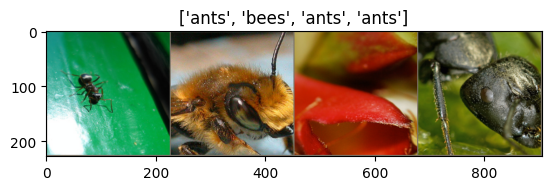

In [3]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.float() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [5]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [6]:
model_ft = models.efficientnet_b3(weights='IMAGENET1K_V1')
num_ftrs = model_ft.classifier[1].in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [7]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 3.6441 Acc: 0.3689
val Loss: 2.1667 Acc: 0.6405

Epoch 1/24
----------
train Loss: 0.5393 Acc: 0.7869
val Loss: 0.9371 Acc: 0.8170

Epoch 2/24
----------
train Loss: 0.5046 Acc: 0.7746
val Loss: 0.9520 Acc: 0.8562

Epoch 3/24
----------
train Loss: 0.3905 Acc: 0.8607
val Loss: 0.7719 Acc: 0.8366

Epoch 4/24
----------
train Loss: 0.4531 Acc: 0.8197
val Loss: 0.7091 Acc: 0.8431

Epoch 5/24
----------
train Loss: 0.3625 Acc: 0.8402
val Loss: 0.5191 Acc: 0.8758

Epoch 6/24
----------
train Loss: 0.4152 Acc: 0.8156
val Loss: 0.8908 Acc: 0.8889

Epoch 7/24
----------
train Loss: 0.3942 Acc: 0.8197
val Loss: 0.5724 Acc: 0.9085

Epoch 8/24
----------
train Loss: 0.3047 Acc: 0.8402
val Loss: 1.1967 Acc: 0.8693

Epoch 9/24
----------
train Loss: 0.3345 Acc: 0.8566
val Loss: 0.4003 Acc: 0.9150

Epoch 10/24
----------
train Loss: 0.3004 Acc: 0.8566
val Loss: 0.4690 Acc: 0.9281

Epoch 11/24
----------
train Loss: 0.2903 Acc: 0.8975
val Loss: 0.4096 Acc: 0.9020

Ep

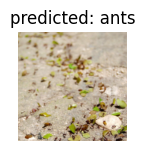

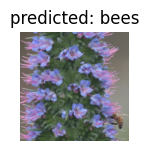

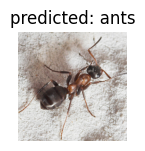

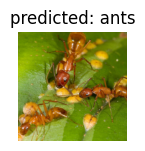

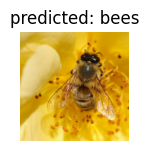

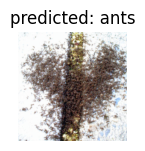

In [8]:
visualize_model(model_ft)



In [9]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# ✅ 올바른 코드: model_conv를 참조
num_ftrs = model_conv.fc.in_features  # ResNet18의 512
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [10]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5549 Acc: 0.7131
val Loss: 0.2238 Acc: 0.9346

Epoch 1/24
----------
train Loss: 0.4983 Acc: 0.7541
val Loss: 0.2626 Acc: 0.9085

Epoch 2/24
----------
train Loss: 0.5933 Acc: 0.7295
val Loss: 0.2468 Acc: 0.8954

Epoch 3/24
----------
train Loss: 0.5870 Acc: 0.7377
val Loss: 0.1846 Acc: 0.9608

Epoch 4/24
----------
train Loss: 0.5013 Acc: 0.7951
val Loss: 0.3532 Acc: 0.8627

Epoch 5/24
----------
train Loss: 0.6724 Acc: 0.7377
val Loss: 0.1829 Acc: 0.9412

Epoch 6/24
----------
train Loss: 0.3349 Acc: 0.8730
val Loss: 0.2529 Acc: 0.9216

Epoch 7/24
----------
train Loss: 0.3830 Acc: 0.8607
val Loss: 0.1924 Acc: 0.9477

Epoch 8/24
----------
train Loss: 0.3377 Acc: 0.8648
val Loss: 0.2097 Acc: 0.9477

Epoch 9/24
----------
train Loss: 0.5132 Acc: 0.7910
val Loss: 0.1880 Acc: 0.9477

Epoch 10/24
----------
train Loss: 0.3603 Acc: 0.7992
val Loss: 0.2048 Acc: 0.9477

Epoch 11/24
----------
train Loss: 0.3637 Acc: 0.8525
val Loss: 0.1885 Acc: 0.9412

Ep

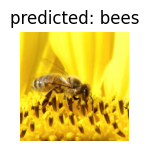

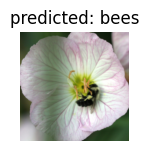

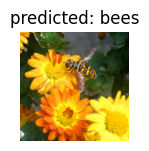

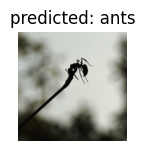

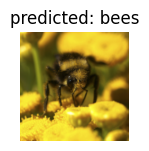

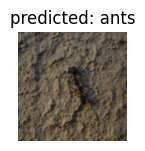

In [11]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [12]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

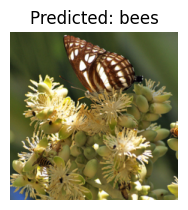

In [13]:
visualize_model_predictions(
    model_conv,
    img_path='../data/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

In [14]:
# EfficientNet-B0 모델 로드 및 설정
print("🔧 EfficientNet 모델 준비 중...")

# EfficientNet-B0 사전학습 모델 로드
efficientnet_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# 마지막 분류 레이어 변경 (2개 클래스: ants, bees)
num_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(num_features, 2)

# 디바이스로 이동
efficientnet_model = efficientnet_model.to(device)

# 손실 함수 및 옵티마이저
criterion_eff = nn.CrossEntropyLoss()
optimizer_eff = optim.Adam(efficientnet_model.parameters(), lr=0.001)

# 학습률 스케줄러
scheduler_eff = lr_scheduler.StepLR(optimizer_eff, step_size=7, gamma=0.1)

print(f"✅ EfficientNet-B0 모델 준비 완료! (Device: {device})")
print(f"📊 출력 클래스 수: 2 (ants, bees)")


🔧 EfficientNet 모델 준비 중...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/songdongseon/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 15.1MB/s]


✅ EfficientNet-B0 모델 준비 완료! (Device: mps)
📊 출력 클래스 수: 2 (ants, bees)


In [15]:
# EfficientNet 학습 함수 (상세 로그 포함)
def train_efficientnet(model, criterion, optimizer, scheduler, num_epochs=15):
    """EfficientNet 모델 학습 with 상세 로그"""
    since = time.time()
    
    # 학습 히스토리 저장
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_efficientnet.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0
        
        for epoch in range(num_epochs):
            print(f'\n{"="*70}')
            print(f'Epoch {epoch+1}/{num_epochs}')
            print(f'{"="*70}')
            
            # 각 에포크는 train과 validation 단계를 가짐
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()
                
                running_loss = 0.0
                running_corrects = 0
                
                # 데이터 반복
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    
                    optimizer.zero_grad()
                    
                    # forward
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                        
                        # backward + optimize (학습 단계에서만)
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    
                    # 통계
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                
                if phase == 'train':
                    scheduler.step()
                
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.float() / dataset_sizes[phase]
                
                # 히스토리 저장
                if phase == 'train':
                    history['train_loss'].append(epoch_loss)
                    history['train_acc'].append(epoch_acc.item())
                else:
                    history['val_loss'].append(epoch_loss)
                    history['val_acc'].append(epoch_acc.item())
                
                # 상세 로그 출력
                print(f'{phase:5s} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} ({running_corrects}/{dataset_sizes[phase]})')
                
                # 최고 모델 저장
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)
                    print(f'✨ New best model! Acc: {best_acc:.4f}')
        
        time_elapsed = time.time() - since
        print(f'\n{"="*70}')
        print(f'🎉 학습 완료!')
        print(f'⏱️  소요 시간: {time_elapsed // 60:.0f}분 {time_elapsed % 60:.0f}초')
        print(f'🏆 최고 검증 정확도: {best_acc:.4f}')
        print(f'{"="*70}')
        
        # 최고 모델 로드
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    
    return model, history

print("📋 EfficientNet 학습 함수 준비 완료")


📋 EfficientNet 학습 함수 준비 완료


In [16]:
# EfficientNet 모델 학습 실행 (15 에포크)
print("🚀 EfficientNet 학습 시작!\n")

efficientnet_model, eff_history = train_efficientnet(
    efficientnet_model, 
    criterion_eff, 
    optimizer_eff, 
    scheduler_eff,
    num_epochs=15
)


🚀 EfficientNet 학습 시작!


Epoch 1/15
train | Loss: 0.6384 | Acc: 0.7254 (177/244)
val   | Loss: 0.4030 | Acc: 0.8497 (130/153)
✨ New best model! Acc: 0.8497

Epoch 2/15
train | Loss: 0.5353 | Acc: 0.7705 (188/244)
val   | Loss: 0.2881 | Acc: 0.8562 (131/153)
✨ New best model! Acc: 0.8562

Epoch 3/15
train | Loss: 0.5297 | Acc: 0.7377 (180/244)
val   | Loss: 0.4678 | Acc: 0.8235 (126/153)

Epoch 4/15
train | Loss: 0.5773 | Acc: 0.7459 (182/244)
val   | Loss: 0.5154 | Acc: 0.7908 (121/153)

Epoch 5/15
train | Loss: 0.5353 | Acc: 0.7500 (183/244)
val   | Loss: 0.3294 | Acc: 0.8562 (131/153)

Epoch 6/15
train | Loss: 0.5827 | Acc: 0.6803 (166/244)
val   | Loss: 0.5139 | Acc: 0.7320 (112/153)

Epoch 7/15
train | Loss: 0.4471 | Acc: 0.8074 (197/244)
val   | Loss: 0.3180 | Acc: 0.8758 (134/153)
✨ New best model! Acc: 0.8758

Epoch 8/15
train | Loss: 0.4576 | Acc: 0.7910 (193/244)
val   | Loss: 0.2518 | Acc: 0.8889 (136/153)
✨ New best model! Acc: 0.8889

Epoch 9/15
train | Loss: 0.4063 | Acc: 0

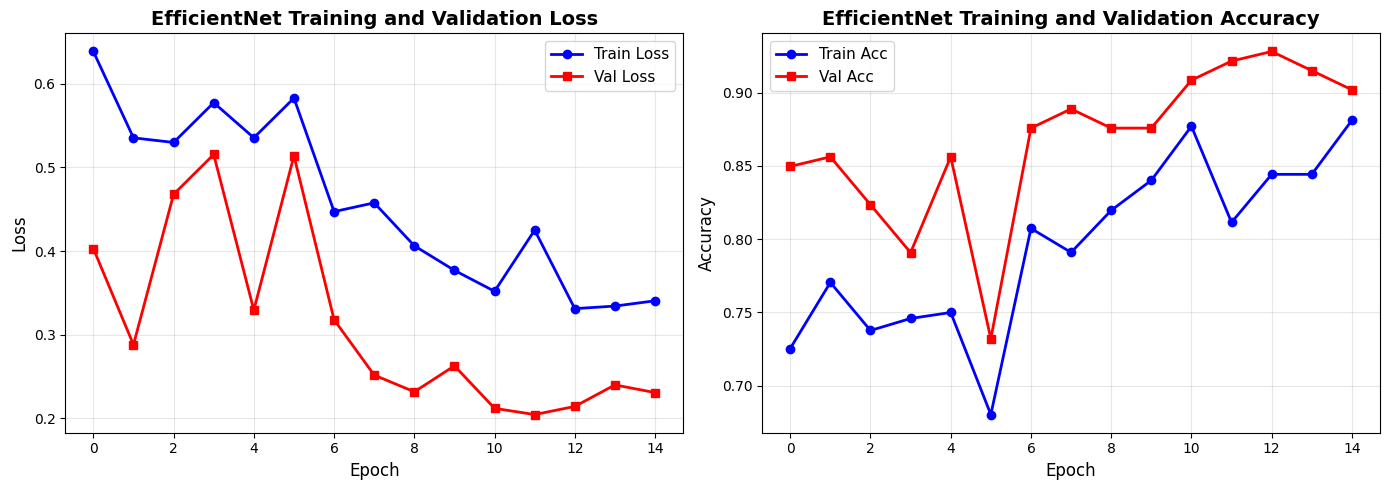


📊 EfficientNet 최종 학습 결과
✓ 최종 학습 정확도: 0.8811 (88.11%)
✓ 최종 검증 정확도: 0.9020 (90.20%)
✓ 최고 검증 정확도: 0.9281 (92.81%)
✓ 최저 검증 Loss: 0.2047


In [17]:
# 학습 결과 그래프 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(eff_history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
axes[0].plot(eff_history['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('EfficientNet Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy 그래프
axes[1].plot(eff_history['train_acc'], 'b-', label='Train Acc', linewidth=2, marker='o')
axes[1].plot(eff_history['val_acc'], 'r-', label='Val Acc', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('EfficientNet Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 결과 출력
print("\n" + "="*60)
print("📊 EfficientNet 최종 학습 결과")
print("="*60)
print(f"✓ 최종 학습 정확도: {eff_history['train_acc'][-1]:.4f} ({eff_history['train_acc'][-1]*100:.2f}%)")
print(f"✓ 최종 검증 정확도: {eff_history['val_acc'][-1]:.4f} ({eff_history['val_acc'][-1]*100:.2f}%)")
print(f"✓ 최고 검증 정확도: {max(eff_history['val_acc']):.4f} ({max(eff_history['val_acc'])*100:.2f}%)")
print(f"✓ 최저 검증 Loss: {min(eff_history['val_loss']):.4f}")
print("="*60)


## 예측 결과 시각화

검증 데이터셋에서 EfficientNet 모델의 예측 결과를 시각화합니다.


In [18]:
# EfficientNet 예측 결과 시각화 함수
def visualize_efficientnet_predictions(model, num_images=8):
    """검증 데이터에서 예측 결과 시각화"""
    was_training = model.training
    model.eval()
    
    images_so_far = 0
    fig = plt.figure(figsize=(16, 10))
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(2, 4, images_so_far)
                ax.axis('off')
                
                # 정답 여부 확인
                true_label = class_names[labels[j]]
                pred_label = class_names[preds[j]]
                is_correct = labels[j] == preds[j]
                
                # 색상 설정 (정답: 초록, 오답: 빨강)
                color = 'green' if is_correct else 'red'
                marker = '✓' if is_correct else '✗'
                title = f'{marker} Pred: {pred_label}\nTrue: {true_label}'
                
                ax.set_title(title, color=color, fontsize=11, fontweight='bold')
                
                # 이미지 표시
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                ax.imshow(img)
                
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    return
    
    model.train(mode=was_training)
    plt.tight_layout()

print("🖼️ 예측 시각화 함수 준비 완료")


🖼️ 예측 시각화 함수 준비 완료


🔍 EfficientNet 예측 결과 (초록: 정답, 빨강: 오답)



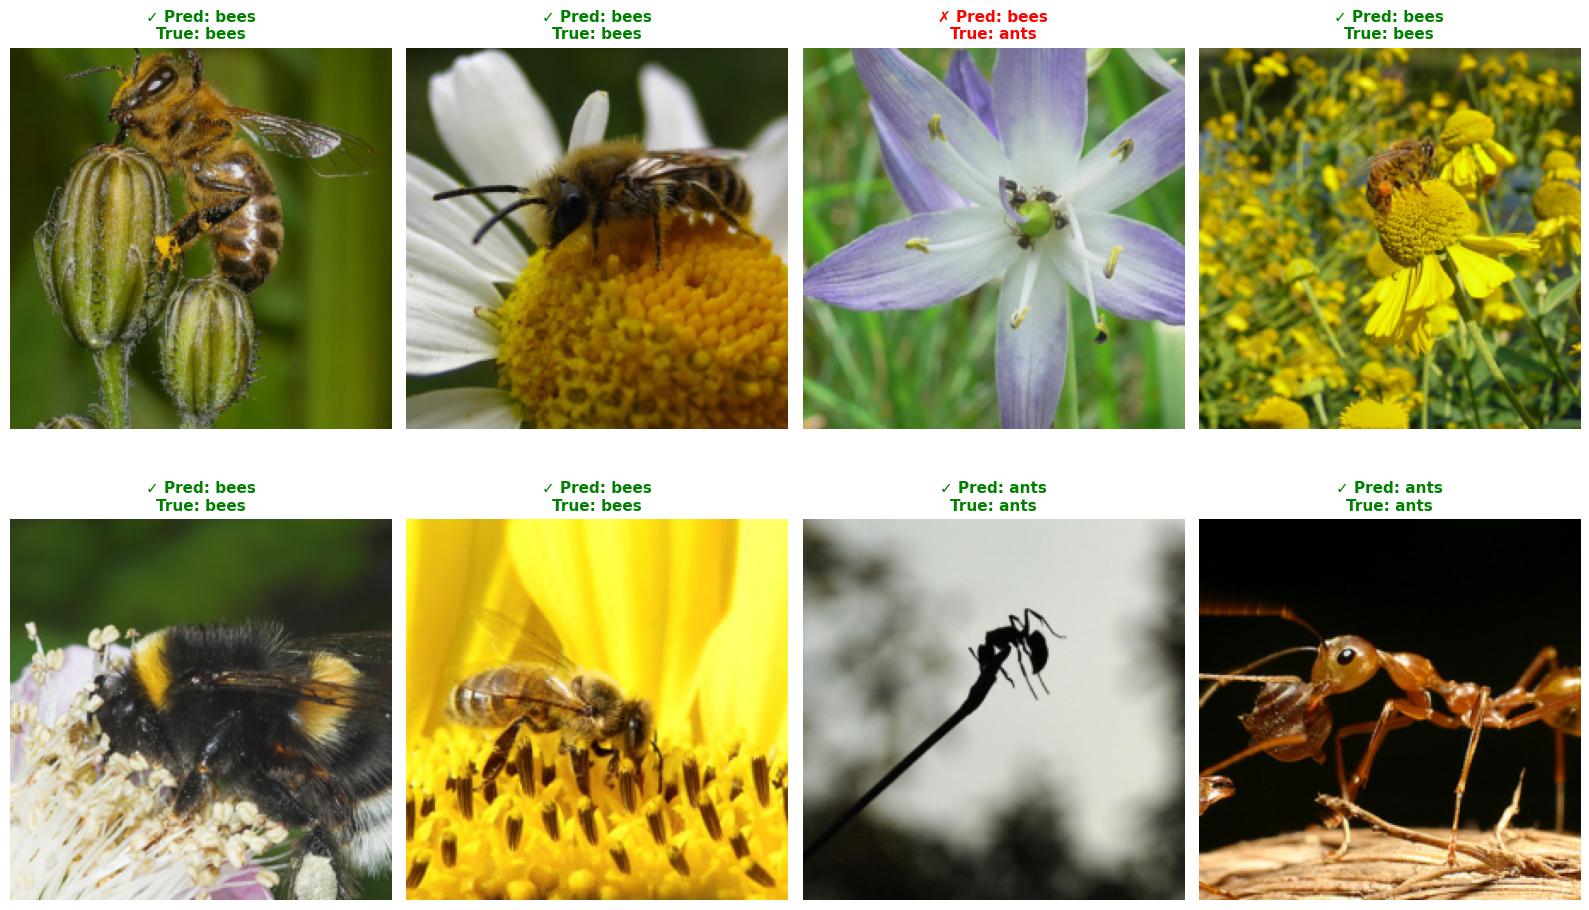

In [19]:
# EfficientNet 예측 결과 시각화 실행
print("🔍 EfficientNet 예측 결과 (초록: 정답, 빨강: 오답)\n")
visualize_efficientnet_predictions(efficientnet_model, num_images=8)
plt.show()


In [20]:
# 검증 데이터셋 전체 평가
def evaluate_efficientnet(model):
    """EfficientNet 모델 전체 평가"""
    model.eval()
    
    all_preds = []
    all_labels = []
    correct_ants = 0
    correct_bees = 0
    total_ants = 0
    total_bees = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # 클래스별 정확도 계산
            for i in range(len(labels)):
                if labels[i] == 0:  # ants
                    total_ants += 1
                    if preds[i] == labels[i]:
                        correct_ants += 1
                else:  # bees
                    total_bees += 1
                    if preds[i] == labels[i]:
                        correct_bees += 1
    
    # 전체 정확도
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    overall_acc = (all_preds == all_labels).sum() / len(all_labels)
    
    # 클래스별 정확도
    ants_acc = correct_ants / total_ants if total_ants > 0 else 0
    bees_acc = correct_bees / total_bees if total_bees > 0 else 0
    
    print("\n" + "="*70)
    print("📊 EfficientNet 최종 평가 결과 (Validation Set)")
    print("="*70)
    print(f"전체 정확도: {overall_acc:.4f} ({(all_preds == all_labels).sum()}/{len(all_labels)}) = {overall_acc*100:.2f}%")
    print(f"\n클래스별 정확도:")
    print(f"  🐜 Ants: {ants_acc:.4f} ({correct_ants}/{total_ants}) = {ants_acc*100:.2f}%")
    print(f"  🐝 Bees: {bees_acc:.4f} ({correct_bees}/{total_bees}) = {bees_acc*100:.2f}%")
    print("="*70)
    
    return all_preds, all_labels

# 평가 실행
eff_predictions, eff_true_labels = evaluate_efficientnet(efficientnet_model)



📊 EfficientNet 최종 평가 결과 (Validation Set)
전체 정확도: 0.9281 (142/153) = 92.81%

클래스별 정확도:
  🐜 Ants: 0.9000 (63/70) = 90.00%
  🐝 Bees: 0.9518 (79/83) = 95.18%


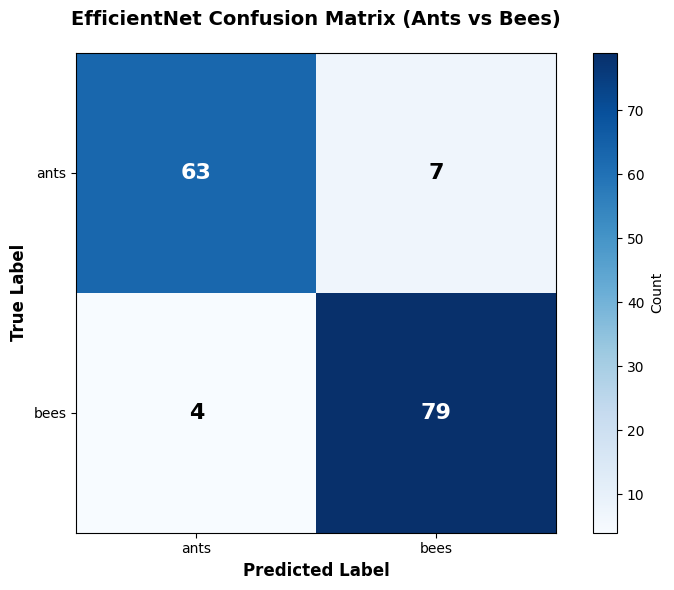


✅ EfficientNet 분석 완료!


In [21]:
# 혼동 행렬 시각화
from sklearn.metrics import confusion_matrix

# 혼동 행렬 계산
cm = confusion_matrix(eff_true_labels, eff_predictions)

# matplotlib로 시각화
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# 축 레이블 설정
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# 각 셀에 숫자 표시
for i in range(len(class_names)):
    for j in range(len(class_names)):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", 
                      color="white" if cm[i, j] > cm.max() / 2 else "black",
                      fontsize=16, fontweight='bold')

# 레이블 및 제목
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet Confusion Matrix (Ants vs Bees)', 
             fontsize=14, fontweight='bold', pad=20)

# 컬러바
plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

print("\n✅ EfficientNet 분석 완료!")
